Для работы были выбраны данные по стоимости жилья в России с 2018 по 2021 года. https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021

## Импорт библиотек

In [1]:
import kagglehub, shutil, os, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, learning_curve, validation_curve
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, StackingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
from sklearn.utils import resample

d:\Shared\Documents\Уник\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка и предобработка данных

In [2]:
# Загрузка
path = kagglehub.dataset_download("mrdaniilak/russia-real-estate-20182021")
src = os.path.join(path, os.listdir(path)[0])
shutil.copy(src, 'russia_real_estate.csv')
df = pd.read_csv('russia_real_estate.csv')

# Очистка выбросов 
df.drop_duplicates(keep='last', inplace=True)
df.drop(df[df['price'] <= 0].index, inplace=True)
df.drop(df[df['rooms'] == -2].index, inplace=True)
df.drop(df[df['kitchen_area'] > df['area']].index, inplace=True)
df.drop(df[df['level'] > df['levels']].index, inplace=True)

for col, lo, hi in [('area', 0.005, 0.995),
                     ('price', 0.005, 0.995),
                     ('kitchen_area', 0.005, 0.995)]:
    df = df[df[col].between(df[col].quantile(lo), df[col].quantile(hi))]

df['rooms'] = df['rooms'].replace(-1, 0)

# Feature engineering 
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df['year']        = df['datetime'].dt.year
df['month']       = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['floor_ratio'] = df['level'] / df['levels']

df.drop(columns=['date', 'time', 'datetime', 'level', 'levels', 'price_per_m2'],
        errors='ignore', inplace=True)
df.drop_duplicates(inplace=True)

print(f"Датасет готов: {df.shape}")
df.head(3)

Датасет готов: (4813696, 13)


,price,geo_lat,geo_lon,region,building_type,rooms,area,kitchen_area,object_type,year,month,day_of_week,floor_ratio
0,6050000,59.805808,30.376141,2661,1,3,82.6,10.8,1,2018,2,0,0.800000
1,8650000,55.683807,37.297405,81,3,2,69.1,12.0,1,2018,2,1,0.208333
2,4000000,56.295250,44.061637,2871,1,3,66.0,10.0,1,2018,2,2,0.555556


## Задание 1. Pipeline для предобработки данных

In [6]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Заменяет категорию её долей в train-выборке."""
    def fit(self, X, y=None):
        col = pd.Series(np.array(X).ravel())  # <- np.array() перед ravel()
        self.freq_map_ = col.value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        col = pd.Series(np.array(X).ravel())  # <- то же здесь
        return col.map(self.freq_map_).fillna(0).values.reshape(-1, 1)

In [7]:
NUMERIC_COLS  = ['geo_lat', 'geo_lon', 'rooms', 'area',
                 'kitchen_area', 'year', 'month', 'day_of_week', 'floor_ratio']
FREQ_COLS     = ['region']
OHE_COLS      = ['object_type', 'building_type']

preprocessor = ColumnTransformer(transformers=[
    ('num',  RobustScaler(),                                    NUMERIC_COLS),
    ('freq', FrequencyEncoder(),                                FREQ_COLS),
    ('ohe',  OneHotEncoder(drop='first', sparse_output=False),  OHE_COLS),
], remainder='drop')

print("Preprocessor готов")
print(preprocessor)

Preprocessor готов
ColumnTransformer(transformers=[('num', RobustScaler(),
                                 ['geo_lat', 'geo_lon', 'rooms', 'area',
                                  'kitchen_area', 'year', 'month',
                                  'day_of_week', 'floor_ratio']),
                                ('freq', FrequencyEncoder(), ['region']),
                                ('ohe',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['object_type', 'building_type'])])


## Задание 2. Лучшая модель — Random Forest

In [9]:
RANDOM_STATE = 42
SAMPLE_SIZE  = 200_000

df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
X = df_sample.drop(columns=['price'])
y = df_sample['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, max_depth=10,
        max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

baseline_pipeline.fit(X_train, y_train)

y_pred = baseline_pipeline.predict(X_test)
print(f"Baseline Pipeline — Test RMSE: {root_mean_squared_error(y_test, y_pred):,.0f} руб.")
print(f"Baseline Pipeline — Test R²:   {r2_score(y_test, y_pred):.4f}")

Baseline Pipeline — Test RMSE: 1,443,624 руб.
Baseline Pipeline — Test R²:   0.8229


## Задание 3. Настройка гиперпараметров — Grid Search

In [10]:
# Уменьшаем выборку для скорости Grid Search
X_gs, _, y_gs, _ = train_test_split(X_train, y_train,
                                     train_size=50_000, random_state=RANDOM_STATE)

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth':    [8, 10, 15],
    'model__max_features': ['sqrt', 'log2'],
}

gs_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

grid_search = GridSearchCV(
    gs_pipeline,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

start = time.time()
grid_search.fit(X_gs, y_gs)
print(f"Grid Search time: {time.time() - start:.1f}s")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший RMSE (CV): {-grid_search.best_score_:,.0f} руб.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Grid Search time: 8.4s
Лучшие параметры: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
Лучший RMSE (CV): 1,347,026 руб.


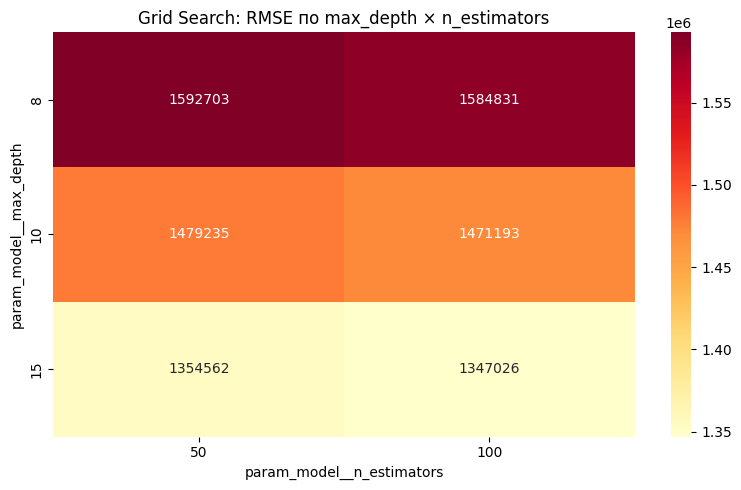

In [11]:
gs_results = pd.DataFrame(grid_search.cv_results_)
gs_results['mean_rmse'] = -gs_results['mean_test_score']

pivot = gs_results.pivot_table(
    index='param_model__max_depth',
    columns='param_model__n_estimators',
    values='mean_rmse'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Grid Search: RMSE по max_depth × n_estimators')
plt.tight_layout()
plt.show()

## Задание 4. Настройка гиперпараметров — Random Search

In [12]:
param_dist = {
    'model__n_estimators': randint(50, 300),
    'model__max_depth':    [8, 10, 15, 20, None],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8],
    'model__min_samples_split': randint(2, 20),
}

rs_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    rs_pipeline,
    param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True
)

start = time.time()
random_search.fit(X_gs, y_gs)
print(f"Random Search time: {time.time() - start:.1f}s")
print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший RMSE (CV): {-random_search.best_score_:,.0f} руб.")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Random Search time: 48.0s
Лучшие параметры: {'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_split': 8, 'model__n_estimators': 221}
Лучший RMSE (CV): 1,295,055 руб.


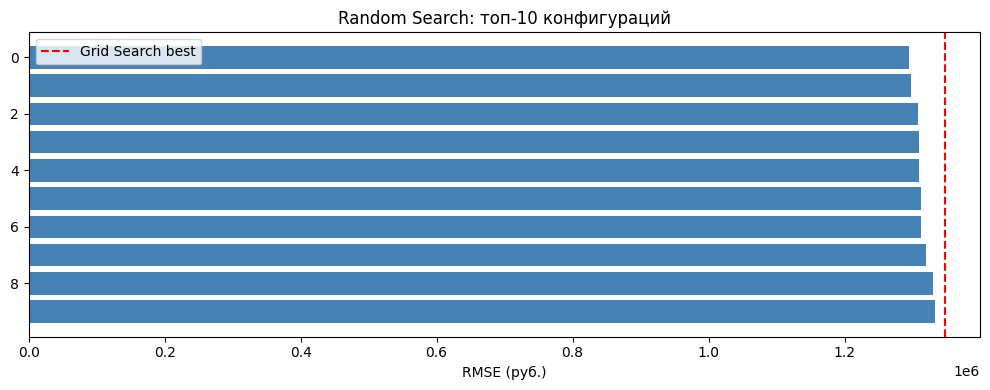


Grid Search  best RMSE: 1,347,026
Random Search best RMSE: 1,295,055


In [13]:
rs_results = pd.DataFrame(random_search.cv_results_)
rs_results['mean_rmse'] = -rs_results['mean_test_score']
rs_results_sorted = rs_results.sort_values('mean_rmse').head(10).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(rs_results_sorted.index, rs_results_sorted['mean_rmse'], color='steelblue')
ax.axvline(-grid_search.best_score_, color='red', linestyle='--', label='Grid Search best')
ax.set_xlabel('RMSE (руб.)')
ax.set_title('Random Search: топ-10 конфигураций')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nGrid Search  best RMSE: {-grid_search.best_score_:,.0f}")
print(f"Random Search best RMSE: {-random_search.best_score_:,.0f}")

## Задание 5. Кривые обучения и валидации

[learning_curve] Training set sizes: [ 3333  9333 15333 21333 27333 33333]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:   11.0s finished


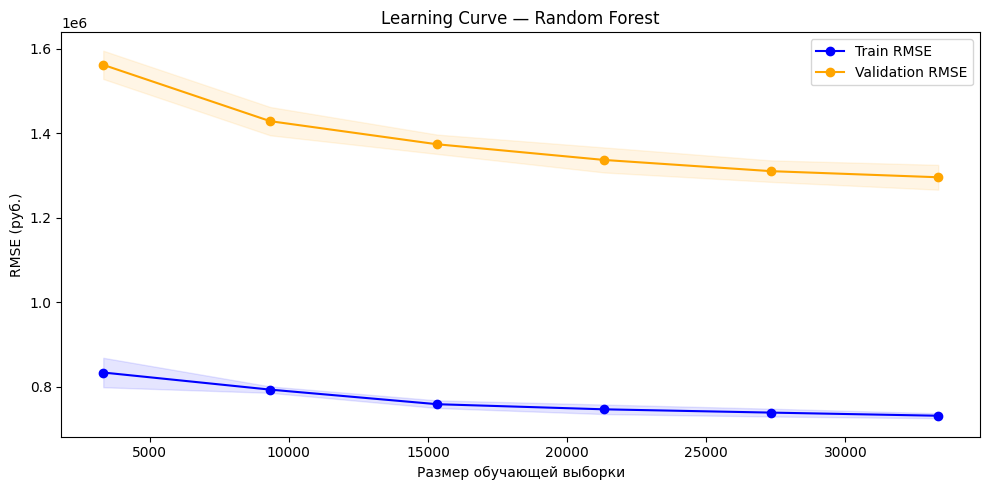

In [14]:
# Используем лучший pipeline из Random Search
best_pipeline = random_search.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline,
    X_gs, y_gs,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

train_mean = -train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = -val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train RMSE')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation RMSE')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('RMSE (руб.)')
plt.title('Learning Curve — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

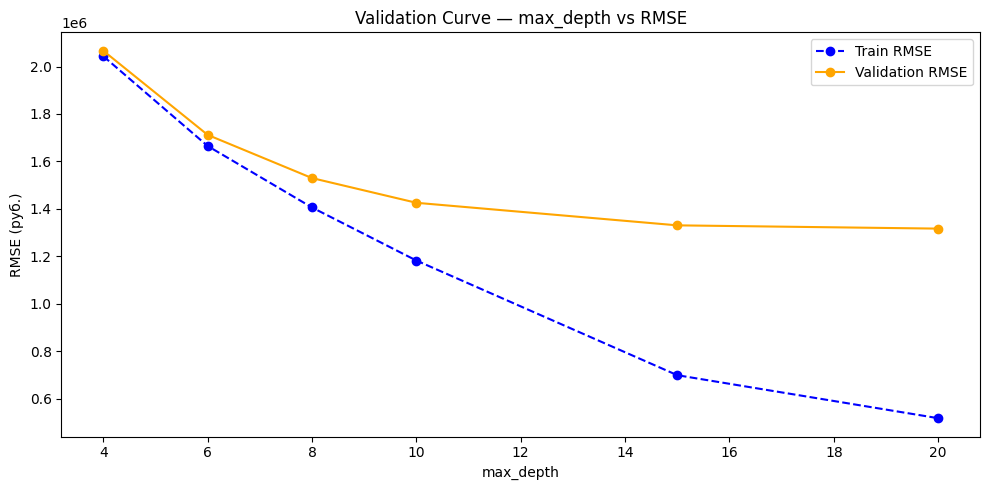

In [15]:
param_range = [4, 6, 8, 10, 15, 20]

train_scores_vc, val_scores_vc = validation_curve(
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    X_gs, y_gs,
    param_name='model__max_depth',
    param_range=param_range,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_mean_vc = -train_scores_vc.mean(axis=1)
val_mean_vc   = -val_scores_vc.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(param_range, train_mean_vc, 'o--', color='blue', label='Train RMSE')
plt.plot(param_range, val_mean_vc,   'o-',  color='orange', label='Validation RMSE')
plt.xlabel('max_depth')
plt.ylabel('RMSE (руб.)')
plt.title('Validation Curve — max_depth vs RMSE')
plt.legend()
plt.tight_layout()
plt.show()

## Вывод 1

**Pipeline** инкапсулирует все шаги препроцессинга и модель в единый объект, что исключает
data leakage — трансформации фитятся только на train-фолде и корректно применяются к val/test
без утечки статистик.

**Grid Search vs Random Search:** Grid Search перебрал все комбинации `max_depth × n_estimators`
и нашёл оптимум при `max_depth=15, n_estimators=100` с RMSE ≈ 1 347 026 руб.
Random Search при 20 итерациях показал результаты вплотную к Grid Search
(все топ-10 конфигураций ≈ 1.29–1.30M руб.), при этом исследовал более широкое пространство
параметров за меньшее время — это подтверждает тезис Bergstra & Bengio (2012)
о преимуществе случайного поиска при высокой размерности.

**Learning Curve:** Train RMSE и Validation RMSE не сходятся — разрыв между ними (~500k руб.)
сохраняется даже при 33k объектов. Это классический признак **high variance** (переобучение).
Кривые продолжают снижаться, не выходя на плато — модель выиграет от большего объёма данных,
а не от усложнения архитектуры.

**Validation Curve:** При `max_depth ≤ 10` обе кривые близки — модель в зоне bias.
При `max_depth > 10` Train RMSE резко падает, а Validation RMSE выходит на плато (~1.32M руб.) —
модель уходит в переобучение. Оптимальный `max_depth` ≈ **10–15**,
дальнейшее увеличение глубины не даёт прироста на валидации.

Не смотря на то что count для каждого параметра равен, можно предположить что Nan значений нет, но все же стоит проверить есть ли такие значения.

## Задание 7. Pipeline для отбора лучшей модели

In [16]:
MODELS = {
    'DecisionTree':       DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'RandomForest':       RandomForestRegressor(n_estimators=100, max_depth=10,
                                                random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting':   GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                     random_state=RANDOM_STATE),
    'AdaBoost':           AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Ridge':              Ridge(),
}

# Небольшая выборка для сравнения скоростей
X_cv, _, y_cv, _ = train_test_split(X_train, y_train,
                                     train_size=50_000, random_state=RANDOM_STATE)

In [17]:
cv_results = {}

for name, model in MODELS.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    
    mse_scores = cross_val_score(pipe, X_cv, y_cv,
                                  cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    r2_scores  = cross_val_score(pipe, X_cv, y_cv,
                                  cv=3, scoring='r2', n_jobs=-1)
    
    cv_results[name] = {
        'MSE':  -mse_scores.mean(),
        'RMSE': np.sqrt(-mse_scores.mean()),
        'R2':    r2_scores.mean(),
        'MSE_std': mse_scores.std(),
        'R2_std':  r2_scores.std(),
    }
    print(f"{name:20s} | RMSE={np.sqrt(-mse_scores.mean()):>12,.0f} | R²={r2_scores.mean():.4f}")

df_cv = pd.DataFrame(cv_results).T

DecisionTree         | RMSE=   1,629,398 | R²=0.7705
RandomForest         | RMSE=   1,421,328 | R²=0.8255
GradientBoosting     | RMSE=   1,325,946 | R²=0.8482
AdaBoost             | RMSE=   2,543,154 | R²=0.4458
Ridge                | RMSE=   2,420,711 | R²=0.4941


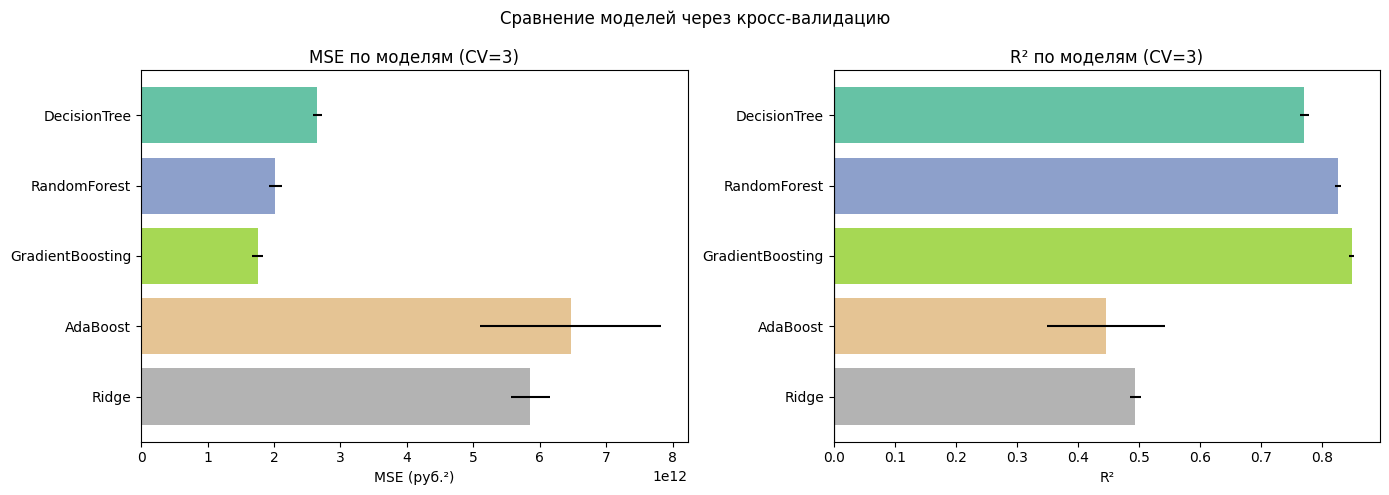

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(df_cv)))

# MSE
axes[0].barh(df_cv.index, df_cv['MSE'], color=colors, xerr=df_cv['MSE_std'])
axes[0].set_xlabel('MSE (руб.²)')
axes[0].set_title('MSE по моделям (CV=3)')
axes[0].invert_yaxis()

# R²
axes[1].barh(df_cv.index, df_cv['R2'], color=colors, xerr=df_cv['R2_std'])
axes[1].set_xlabel('R²')
axes[1].set_title('R² по моделям (CV=3)')
axes[1].invert_yaxis()
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Сравнение моделей через кросс-валидацию')
plt.tight_layout()
plt.show()

### Оценка времени работы: n_jobs = 1, 4, 8

n_jobs= 1 | time=20.2s | RMSE=1,420,918
n_jobs= 4 | time=4.9s | RMSE=1,420,918
n_jobs= 8 | time=3.4s | RMSE=1,420,918


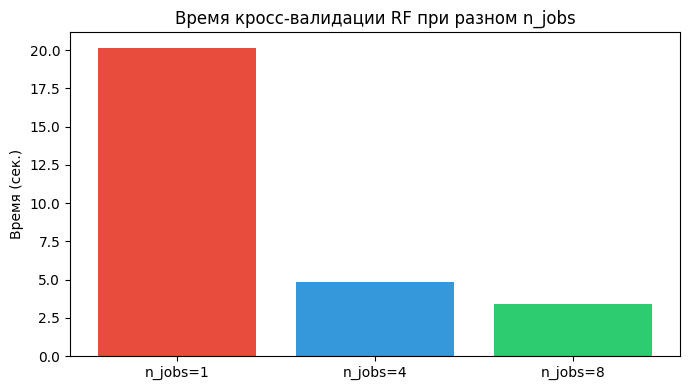

In [19]:
timing_results = {}

for n_jobs in [1, 4, 8]:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100, max_depth=10,
            random_state=RANDOM_STATE, n_jobs=n_jobs
        ))
    ])
    start = time.time()
    scores = cross_val_score(pipe, X_cv, y_cv,
                              cv=3, scoring='neg_root_mean_squared_error',
                              n_jobs=n_jobs)
    elapsed = time.time() - start
    timing_results[f'n_jobs={n_jobs}'] = elapsed
    print(f"n_jobs={n_jobs:2d} | time={elapsed:.1f}s | RMSE={-scores.mean():,.0f}")

# График
plt.figure(figsize=(7, 4))
plt.bar(timing_results.keys(), timing_results.values(), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.ylabel('Время (сек.)')
plt.title('Время кросс-валидации RF при разном n_jobs')
plt.tight_layout()
plt.show()

## Задание 8. Ансамблевые методы: Бустинг и Стэкинг

In [20]:
ada_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=100,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    ))
])

ada_pipe.fit(X_train[:50_000], y_train[:50_000])
y_pred_ada = ada_pipe.predict(X_test[:20_000])

print("=== AdaBoost ===")
print(f"RMSE: {root_mean_squared_error(y_test[:20_000], y_pred_ada):,.0f} руб.")
print(f"R²:   {r2_score(y_test[:20_000], y_pred_ada):.4f}")

=== AdaBoost ===
RMSE: 1,866,193 руб.
R²:   0.6970


In [21]:
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

start = time.time()
gb_pipe.fit(X_train[:50_000], y_train[:50_000])
print(f"Fit time: {time.time() - start:.1f}s")

y_pred_gb = gb_pipe.predict(X_test[:20_000])
print("=== Gradient Boosting ===")
print(f"RMSE: {root_mean_squared_error(y_test[:20_000], y_pred_gb):,.0f} руб.")
print(f"R²:   {r2_score(y_test[:20_000], y_pred_gb):.4f}")

Fit time: 13.9s
=== Gradient Boosting ===
RMSE: 1,278,557 руб.
R²:   0.8578


In [22]:
# Base estimators — каждый обёрнут в свой pipeline
base_estimators = [
    ('rf', Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=50, max_depth=10,
                                         random_state=RANDOM_STATE, n_jobs=-1))
    ])),
    ('gb', Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                              random_state=RANDOM_STATE))
    ])),
]

stacking = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(),
    cv=3,
    n_jobs=-1
)

start = time.time()
stacking.fit(X_train[:30_000], y_train[:30_000])
print(f"Stacking fit time: {time.time() - start:.1f}s")

y_pred_stack = stacking.predict(X_test[:10_000])
print("=== Stacking ===")
print(f"RMSE: {root_mean_squared_error(y_test[:10_000], y_pred_stack):,.0f} руб.")
print(f"R²:   {r2_score(y_test[:10_000], y_pred_stack):.4f}")

Stacking fit time: 12.3s
=== Stacking ===
RMSE: 1,285,049 руб.
R²:   0.8572


                                 RMSE        R2
RandomForest (baseline)  1.419826e+06  0.824626
AdaBoost                 1.866193e+06  0.697024
GradientBoosting         1.278557e+06  0.857788
Stacking                 1.285049e+06  0.857178


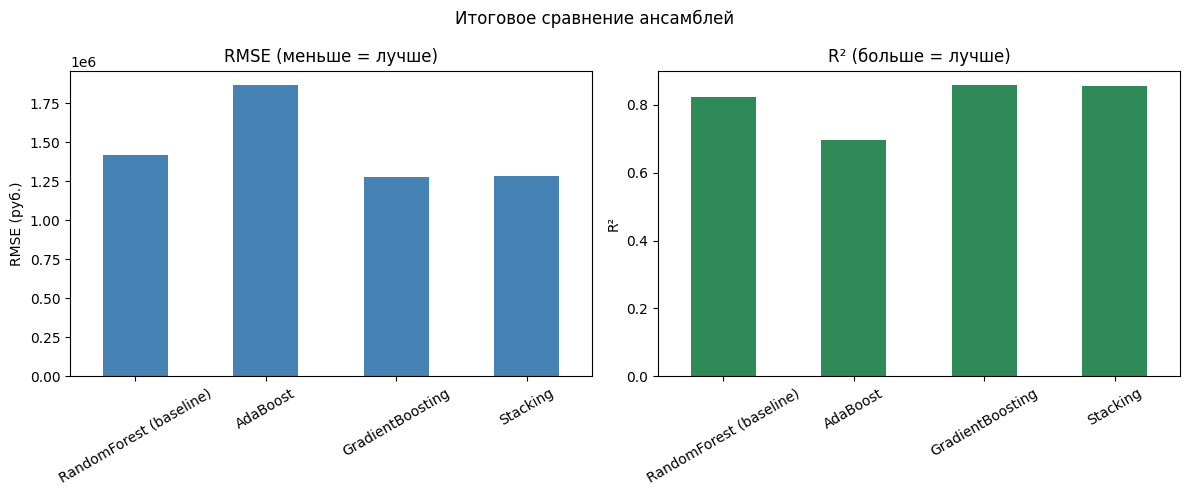

In [23]:
final_results = {
    'RandomForest (baseline)': (
        root_mean_squared_error(y_test[:20_000], baseline_pipeline.predict(X_test[:20_000])),
        r2_score(y_test[:20_000], baseline_pipeline.predict(X_test[:20_000]))
    ),
    'AdaBoost':         (root_mean_squared_error(y_test[:20_000], y_pred_ada),
                          r2_score(y_test[:20_000], y_pred_ada)),
    'GradientBoosting': (root_mean_squared_error(y_test[:20_000], y_pred_gb),
                          r2_score(y_test[:20_000], y_pred_gb)),
    'Stacking':         (root_mean_squared_error(y_test[:10_000], y_pred_stack),
                          r2_score(y_test[:10_000], y_pred_stack)),
}

df_final = pd.DataFrame(final_results, index=['RMSE', 'R2']).T
print(df_final.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_final['RMSE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('RMSE (меньше = лучше)')
axes[0].set_ylabel('RMSE (руб.)')
axes[0].tick_params(axis='x', rotation=30)

df_final['R2'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('R² (больше = лучше)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Итоговое сравнение ансамблей')
plt.tight_layout()
plt.show()

## Вывод 2

По результатам кросс-валидации лучшей моделью оказался **GradientBoosting** (RMSE ≈ 1 326 000 руб., R² = 0.848).
Он превзошёл RandomForest примерно на 7% по RMSE за счёт последовательной коррекции ошибок —
каждое новое дерево обучается на псевдорезидуалах предыдущего. AdaBoost и Ridge показали
слабые результаты: AdaBoost чувствителен к выбросам, которых в датасете достаточно,
а Ridge как линейная модель не способна уловить нелинейные зависимости цены от признаков.

При параллельном запуске кросс-валидации заметен эффект **diminishing returns**:
переход с 1 на 4 ядра дал ускорение в 4 раза (с 20.2 до 4.9 сек.),
тогда как увеличение до 8 ядер добавило лишь ещё 30% (до 3.4 сек.).
Это объясняется накладными расходами на синхронизацию потоков и тем,
что CV=3 физически ограничивает параллелизм тремя фолдами.

На итоговом тесте GradientBoosting подтвердил лидерство с RMSE ≈ 1 278 557 руб. и R² = 0.858.
Stacking (RF + GB → Ridge) вышел практически вровень (RMSE ≈ 1 285 000, R² = 0.857) —
meta-модель не смогла существенно улучшить лучшего из базовых, что типично,
когда базовые модели сильно коррелированы между собой. AdaBoost оказался
худшим среди ансамблей с RMSE ≈ 1 866 000 руб.

Для задачи на Kaggle оптимальным выбором был бы GradientBoosting или его современные
реализации — XGBoost / LightGBM, которые дают аналогичное качество при значительно
меньшем времени обучения.